In [89]:
#This cell sets runtime configuration to ensure consistent notebook execution across environments.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

## **IPOlogists**

### Anna Kester & Will Zambito

https://github.com/A-Kester/ipologists.git

### **Abstract**

This project addresses the issue of IPO underpricing, which results in companies often leaving signficant capital on the table if market prices surge after going public. Our approach to this problem is to develop machine learning models to predict whether an IPO is likely to be underpriced, fairly priced, or overpriced. We use four types of models, including Logistic Regression, Artificial Neural Network, Random Forest, and XGBoost, to capture nonlinear relationships in financial, macroeconomic, and risk features. For comparison, always predicting 'underpriced' results in a baseline accuracy of 60%. We find that XGBoost outperforms the other models, with an accuracy of **71%** on binary classification of the full dataset, exclusive of risk features.

### **Introduction**

IPO underpricing occurs when the offer price of a company that is going public is set below the closing price of the market on the first day of trading. Underpricing results in economic inefficiency and the company "leaving money on the table" since demand existed in the market and they could have set a higher offer price to raise more capital. Being able to systematically predict IPO underpricing would improve the efficiency of allocating capital and reduce information aysmmetry between the company and the market. 

Recent literature has increasingly used machine learning to predict IPO underpricing and first-day returns. These studies suggest that machine learning is better suited than traditional linear regression methods to capture the complex, non-linear features that influence IPO performance. 

Sonsare et al. compare the results of several models, including AdaBoost, Random Forest, Logistic Regression, ANN and SVM, to predict IPO underperformance. They find that ANN models performed the best with an accuracy of 68.1%. They also highlight that each model had strengths and weaknesses with XGBoost and Random Forest handling imbalanced or missing data well, Logistic Regression providing insights into the weights of individual features, and AdaBoost and SVMs improving classification accuracy and handling nonlinear data well[<sup id="fn1-back">[1]</sup>](#fn1). 

Similarly, Colak et al. use machine learning models to predict IPO first-day returns using a sample of 4980 IPOs. They use firm-level accounting information as well as "established" IPO predictor variables such as firm age, venture capital dummy, underwriter reputation and more. They find that XGBoost outperformed the other models in predicting the direction and magnitude of IPO first-day returns. They attribute this to XGBoost's ability to efficiently handle missing values, built in L1 and L2 regularization, and insensitivity to outliers[<sup id="fn2-back">[2]</sup>](#fn2). 

Zhao and Long apply Deep Learning, Decision Trees, Random Forest, and SVM to predict IPO underpricing in China. Their results show that Random Forest achieved the highest accuracy at 89.7%, with Deep Learning following closely behind at 89.4% accuracy. They find that traditional corporate financial indicators such as earnings per share and net asset value per share were the most important and predictive features[<sup id="fn3-back">[3]</sup>](#fn3).

These studies demonstrate the growing role of machine learning in IPO underpricing and returns prediction, though models and their application requires further research.

### **Values**

Potential users of this project include investors, underwriters, financial analysts, and companies preparing to go public. In addition to the users of this project, stock exchanges and regulators, such as the NYSE and SEC, may be affected by improvements in IPO pricing efficiency, information transparency, and subsequent regulatory responses. Technology that improves the prediction of IPO underpricing could benefit companies seeking to raise capital more efficiently and investors attempting to make more informed decisions. However, there is also potential for harm if predictive models reinforce market inequalities, are used unfairly by institutional investors with greater technological access, or increase volatility by encouraging speculative trading. 

Our personal interest in this problem comes from the intersection of financial markets, economic efficiency, and machine learning. We are motivated by the challenge of applying predictive models to real-world market behavior that is complex and nonlinear. We believe that technology that improves transparency and reduces information asymmetry in IPO markets could contribute to a more efficient and equitable allocation of capital. However, The impact of this technology depends how responsibly it is implemented, used, and regulated. 

### **Data**

**Sources and Collection**
Our dataset draws from three primary sources, merged into two final datasets used for modeling.

***IPO Data (Bloomberg Terminal)***: Historical IPO data was obtained from the Bloomberg Terminal at Davis Family Library, Middlebury College. Access to the Bloomberg Terminal is granted to all Middlebury College students. The raw data arrived in two separate exports, one covering 2000-2009 and one covering 2010-present, which were concatenated and sorted by pricing date. This data was exported from Bloomberg to Excel and converted to CSV. It covers all US IPOs from 2000 to present. Each row represents a single US IPO, identified by a ticker ending in "US", which we cleaned to a standard ticker format. 

***Macroeconomic Data (FRED API)***: Macroeconomic indicators were pulled programmatically via the Federal Reserve Economic Data (FRED) API. Access is granted by creating a free account and [requesting an API key](https://fred.stlouisfed.org/docs/api/api_key.html). The monthly macroeconomic indicators were merged with the Bloomberg IPO data via left join on a `month_key`. This means all IPOs priced in the same month share the same macroeconomic values, which is a known limitation of our approach.

***S-1 Risk Filings (SEC EDGAR)***: S-1 filings were obtained from the SEC EDGAR database using the `sec-edgar-downloader` Python package. It is a free-to-use package that requires only an email to obtain information from the SEC EDGAR, the data was obtained programmatically. We extracted the risk factor section for each filing using regex, then applied a quality filter that only retained extractions that contained risk-related keywords (e.g. "adverse", "risk", "litigation", "volatile"...). This removed poorly extracted texts that were too short or contained the wrong section. The remaining texts were sent to GPT-4o-mini via the OpenAI API at low temperature to generate four integer risk scores on a 1-10 scale. Scores were validated to be within range and contain all four required keys.

**Dataset Structure**

In [90]:

import pandas as pd

full = pd.read_csv('data/final/dataset_full.csv')
risk = pd.read_csv('data/final/dataset_with_risk.csv')

print(f"Full Dataset: {full.shape}")
print(f"Risk Dataset: {risk.shape}")

Full Dataset: (6110, 24)
Risk Dataset: (862, 28)


In [91]:
full.sample(n=5)

,Pricing Date,Issuer Name,Offer Size (M),Offer Price,Offer To 1st Close,Initial Pub Offer (Shares Offered),Industry Sector,Market Cap at Offer (M),Instit Owner (% Shares Out),Primary Exchange,...,has_bulge_bracket,vix,nasdaq,fed_funds,treasury_10y,cpi,unemployment,gdp,ipo_volume,market_return_1m
5907,2025-02-13,Inflection Point Acquisition C,75.0000,10.0,0.300000,7500000.0,Diversified,77.375,50.62420,NASDAQ GM,...,0,19.63,18847.28,4.33,4.24,318.961,4.0,23548.210,100.6008,0.016398
3255,2015-04-22,National Storage Affiliates Trust,299.0000,13.0,0.000000,20000000.0,Financial,0.000,107.89100,New York,...,1,14.55,4941.42,0.12,2.05,236.222,5.4,18782.243,99.7225,-0.012622
3875,2018-07-17,Crinetics Pharmaceuticals Inc,117.3000,17.0,44.176472,6000000.0,"Consumer, Non-cyclical",406.436,113.45400,NASDAQ GS,...,1,12.83,7671.79,1.82,2.96,251.018,4.0,20044.077,104.6030,0.009161
500,2002-04-25,BlackRock Virginia Municipal Bond Trust,22.5750,15.0,0.000000,1340000.0,Financial,0.000,11.15100,New York,...,1,21.91,1688.23,1.75,5.11,179.300,5.9,14460.848,88.7504,0.065758
2624,2013-05-08,TriState Capital Holdings Inc,75.3825,11.5,9.478261,5700000.0,Financial,329.790,2.15924,,...,0,16.30,3455.91,0.11,2.16,231.893,7.5,17709.671,98.1988,0.018751


In [92]:
full.describe()

,Offer Size (M),Offer Price,Offer To 1st Close,Initial Pub Offer (Shares Offered),Market Cap at Offer (M),Instit Owner (% Shares Out),underpriced,offer_size_to_mktcap,has_bulge_bracket,vix,nasdaq,fed_funds,treasury_10y,cpi,unemployment,gdp,ipo_volume,market_return_1m
count,6110.000000,6110.000000,5613.000000,6.036000e+03,6110.000000,3.595000e+03,6110.000000,4751.000000,6110.000000,6110.000000,6110.000000,6093.000000,6110.000000,6093.000000,6093.000000,5742.000000,6093.000000,6041.000000
mean,253.971223,13.158318,209.248971,1.538570e+07,658.218822,4.163696e+01,0.600491,0.514655,0.492799,19.086440,7098.146835,1.739069,3.017444,236.195394,5.666109,18818.356117,97.895499,0.016547
std,619.665461,14.955142,7469.612522,2.341912e+07,2581.271302,3.984574e+01,0.489838,0.348516,0.499989,6.387334,5524.548099,2.084152,1.479901,39.071562,1.762114,2608.046650,4.071619,0.056553
min,0.000000,0.000000,-100.000000,4.000000e+03,0.000000,1.320000e-09,0.000000,0.001254,0.000000,9.510000,1172.060000,0.050000,0.550000,170.000000,3.500000,14183.120000,82.542900,-0.229016
25%,53.373450,10.000000,0.000000,5.000000e+06,36.122500,6.656910e+00,0.000000,0.224108,0.000000,14.197500,2525.090000,0.090000,1.740000,203.100000,4.300000,16611.690000,95.228800,-0.015238
50%,130.000000,11.000000,1.300000,9.000000e+06,229.939000,2.612550e+01,1.000000,0.354775,0.000000,17.150000,4580.270000,0.400000,2.670000,236.918000,5.400000,18666.621000,99.140900,0.016398
75%,275.000000,17.000000,16.000000,2.000000e+07,489.982750,7.672535e+01,1.000000,0.966285,1.000000,23.160000,12198.740000,3.500000,4.270000,262.687000,6.400000,21082.134000,100.972600,0.053068
max,19650.400000,1000.000000,531150.000000,6.000000e+08,81247.200000,1.930450e+02,1.000000,1.277778,1.000000,55.840000,23724.960000,6.530000,6.680000,326.031000,14.800000,24055.749000,106.086000,0.191947


The ***full dataset*** contains 6,110 IPOs and 24 columns, spanning 2000 to present. The ***risk dataset*** contains 862 IPOs and 28 columns, which corresponds to the subset of the full dataset for which we successfully obtained and scored S-1 filings. It was created via an inner join on ticker between the full dataset and the GPT-4o-mini risk scores.

**Targets**

For our approach we define two classification targets:
- ***Binary***: `underpriced` - 1 if the IPO's first-day return (`Offer To 1st Close`) is positive, 0 otherwise. 
- ***3-Class***: `three_class` - 0 if first-day return < 0% (overpriced), 1 if between 0-20% (mildly underpriced), 2 if > 20% (strongly underpriced).

**Features**

We have 15 baseline features that span over four categories:

| Category | Features|
|----------|----------|
| IPO Characteristics | Offer Size, Offer Price, Shares Offered, Market Cap, Offer Size / Market Cap, Has Bulge Bracket |
| Market Conditions | VIX, NASDAQ, IPO Volume, 1-Month Market Return |
| Interest Rates | Fed Funds Rate, 10-Year Treasury Yield |
| Macroeconomic | CPI, Unemployment, GDP |

The risk dataset adds four GPT-4o-mini engineered features: `regulatory_risk`, `competitive_risk`, `financial_risk`, and `overall_risk`.

**Missing Values**

Missing values are handled at the pipeline level rather than during data cleaning, which will be described in more depth in "Our Approach" section. Essentially, missing values were imputed using the median value. The median imputation was used because financial data tends to be skewed, and the median provides a more robust measure of central tendency that is less influenced by extreme outliers. 

**Exploratory Data Visualization**

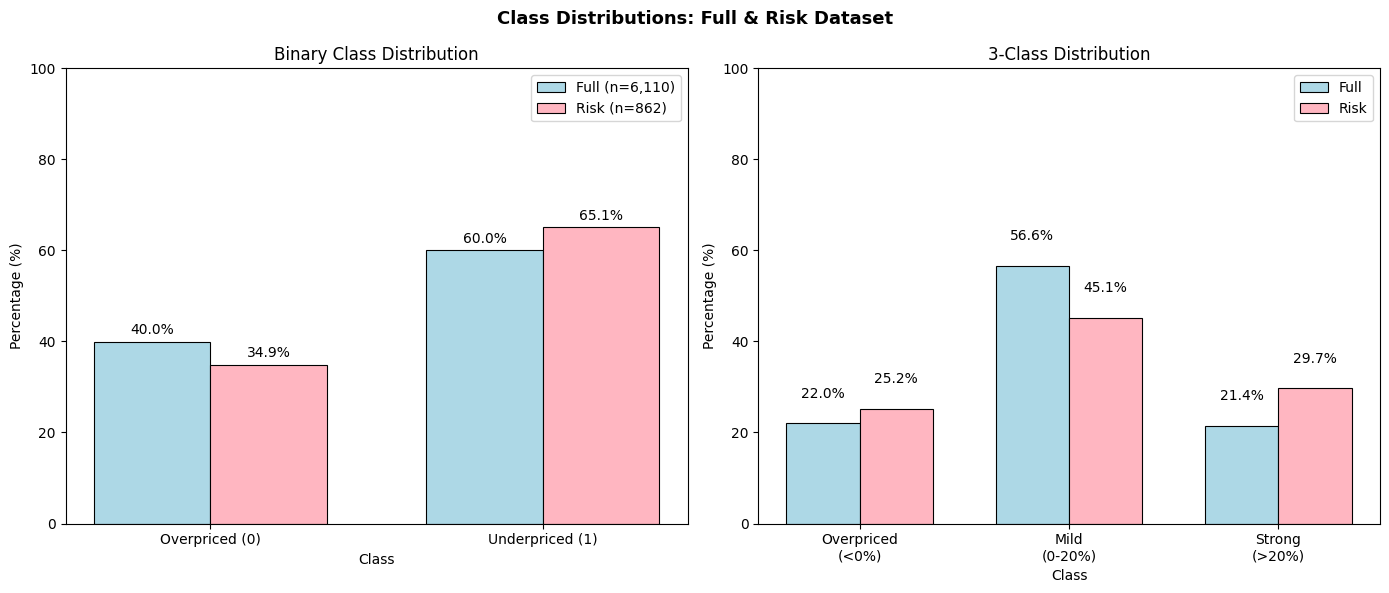

In [93]:
import matplotlib.pyplot as plt
import numpy as np
from src.pipeline import three_class

full_3c= three_class(full)
risk_3c = three_class(risk)

fig, axes = plt.subplots(1,2,figsize=(14,6))
fig.suptitle("Class Distributions: Full & Risk Dataset", fontsize=13, fontweight = "bold")
width=0.35
ax1= axes[0]
x=np.arange(2)
full_binary = full["underpriced"].value_counts().sort_index() / len(full) *100
risk_binary = risk["underpriced"].value_counts().sort_index() / len(risk) *100

bars1 = ax1.bar(x - width/2, full_binary.values, width, label="Full (n=6,110)", color="lightblue", edgecolor="black", linewidth=0.8)
bars2 = ax1.bar(x + width/2, risk_binary.values, width, label="Risk (n=862)",color="lightpink", edgecolor="black", linewidth=0.8)

ax1.set_title("Binary Class Distribution")
ax1.set_xlabel("Class")
ax1.set_ylabel("Percentage (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(["Overpriced (0)", "Underpriced (1)"])
ax1.set_ylim(0, 100)
ax1.legend()

for bar, pct in zip(bars1, full_binary.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
for bar, pct in zip(bars2, risk_binary.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax2 = axes[1]
x = np.arange(3)
full_3class = full_3c["three_class"].value_counts().sort_index() / len(full_3c) * 100
risk_3class = risk_3c["three_class"].value_counts().sort_index() / len(risk_3c) * 100

bars3 = ax2.bar(x - width/2, full_3class.values, width, label="Full", color="lightblue", edgecolor="black", linewidth=0.8)
bars4 = ax2.bar(x + width/2, risk_3class.values, width, label="Risk", color="lightpink", edgecolor="black", linewidth=0.8)
ax2.set_title("3-Class Distribution")
ax2.set_xlabel("Class")
ax2.set_ylabel("Percentage (%)")
ax2.set_xticks(x)
ax2.set_xticklabels(["Overpriced\n(<0%)", "Mild\n(0-20%)", "Strong\n(>20%)"])
ax2.set_ylim(0, 100)
ax2.legend()

for bar, pct in zip(bars3, full_3class.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
for bar, pct in zip(bars4, risk_3class.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


The figure above shows the class distribution for both the full dataset and the risk dataset. In the binary case, approximately 60% of IPOs in the full dataset are underpriced compared to 65.1% in the risk dataset. This suggests the risk dataset skews slightly more toward underpriced IPOs likely because S-1 filings are more commonly available for larger offerings that tend to generate stronger first-day demand. The 3-class breakdown reveals that the mild category (0-20%) return dominates both datasets at roughly 56.6% and 45.1%, for full and risk respectively. The overpriced and strongly underpriced IPOs are roughly symmetric minorities at around 25% each. This class imbalance motivated our use of class weights in training across all models. 

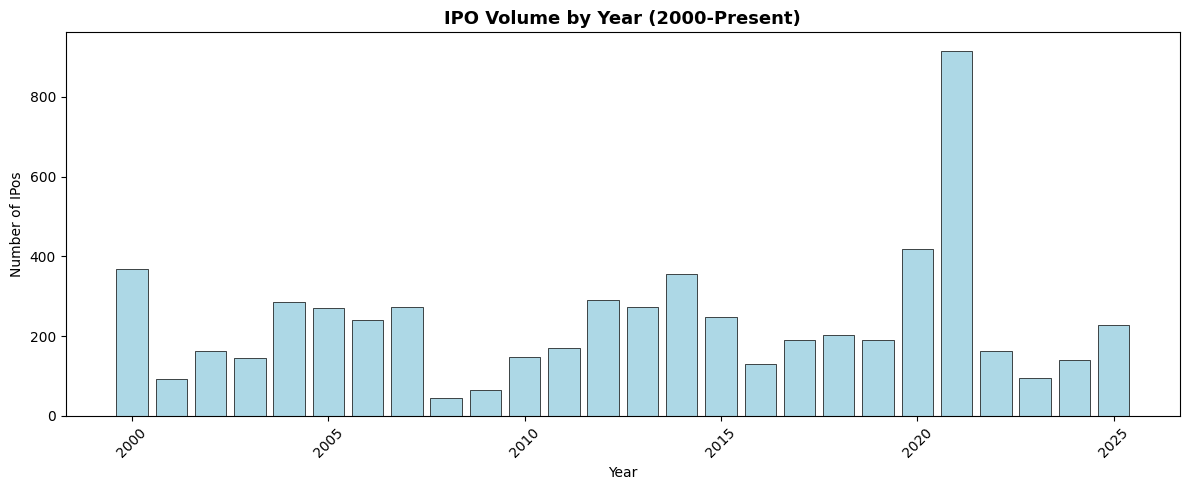

In [94]:
fig,ax = plt.subplots(figsize=(12,5))
full["Pricing Date"] = pd.to_datetime(full["Pricing Date"])
full["year"] = full["Pricing Date"].dt.year
ipo_by_year = full.groupby("year").size()

ax.bar(ipo_by_year.index, ipo_by_year.values, color="lightblue", edgecolor="black", linewidth=0.5)
ax.set_title("IPO Volume by Year (2000-Present)", fontsize=13, fontweight = "bold")

ax.set_xlabel("Year")
ax.set_ylabel("Number of IPos")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The figure above shows how IPO volume exhibits patterns driven by macroeconomic conditions. Looking at the chart, we notice a collapse in IPO volume following the dot-com bust after the year 2000, and another sharp decline during the 2008-2009 financial crisis. We also notice how the 2020-2021 period saw a large spike in IPO activity driven by the SPAC boom. These patterns motivate our inclusion of macroeconomic features as predictors, since market environment clearly influences IPO timing and performance. 

### **Approach**

**Features and Targets**
We use 15 baseline features as predictors, spanning four categories as described in the "Data" section. The predictors span four categories: IPO characteristics, market conditions, interest rates, and macroeconomic indicators. Risk factors are also used in the risk dataset.

We train on two targets:
- ***Binary*** (`underpriced`)
- ***3-Class*** (`three_class`)

**Data Subsetting and Split**

All of our models use an identical 80/20 stratified train/test split with `random_state=42`, ensuring that every model trains and evaluates on the exact same rows. Stratification preserves the class distribution in both splits, which is important given the class imbalance. The test set contains 1,222 rows for the full dataset, and ~172 rows for the risk dataset. 

We train on two datasets:
- ***Full Dataset*** (6,110 IPOs) - all four models are trained on the full dataset to evaluate what model is best at binary and 3-class classification for IPO underpricing.
- ***Risk Dataset*** (862 IPOs) - XGBoost is the only model we run on the risk dataset. XGBoost was chosen because it was our best binary classifier with most balanced precision and recall across classes. We ran it twice on the risk dataset, once with the 15 baseline features and once with the 4 risk scores. Both runs use the same 80/20 split and same hyperparameters, so any performance difference isolates the marginal contribution of our risk features.

**Data Pipelines**

Preprocessing differs by model type, it was implemented in `src/pipeline.py`:

- `XGBoostPipeline` does not impute for NaN values since XGBoost handles them natively, and no scaling is needed since it is a tree-based model. Feature magnitude does not affect it. 
- `ScaledPipeline` was used for neural network, logistic regression, and random forest. It fits the median values and fills NaN with them. A `StandardScaler` is then applied to normalize our financial data. Random forest is tree-based and doesn't benefit from scaling, but is not harmed by it either, so we use the same pipeline for simplicity.


**Models**

We trained four models:
|Model|Implementation|Reasoning|
|-------|---------------|-----------|
| Logistic Regression | Custom PyTorch (gradient descent) | Used as a Linear baseline to establish a lower bound |
| Neural Network | Custom PyTorch (`nn.Module`) |Non-linear model used to learn complex feature interactions|
| Random Forest | Custom PyTorch (from scratch) |Research demonstrate the effectiveness of tree based model |
| XGBoost | `xgboost` library | Research indicate it is one of the strongest model for tabular financial data |


***Logistic Regression***: Our logistic regression was implemented from scratch using a weight matrix `W` of shape `(d_feature, k_classes)`, softmax, and gradient descent with cross-entropy loss. We trained it for 6,000 epochs with a learning rate of 0.001. 

***Neural Network***: Our neural network is a two-hidden-layer MLP that uses BatchNorm and Dropout. We used `hidden_dim=256` for binary and `hidden_dim=128` for 3-class. It was trained using the Adam optimizer with a learning rate of 0.0001 for 500 and 1000 epochs respectively. 

***Random Forest***: Our random forest is implemented from scratch using PyTorch tensors. Each tree is grown using Gini impurity to find the best split. We used 40 trees with a `max_depth=6`for binary and `max_depth=8` for 3-class.

***XGBoost***: We used the `XGBClassifier` from the `xgboost` library. For binary classification, we used `n_estimators=4000`, `max_depth=6`, and `learning_rate=0.01`. For 3-class classification, we used `n_estimators=2000` with `objective='multi:softmax'` and, `n_estimators=4000`.


**Hardware**

All models were trained on a MacBook Pro (Apple M2 Pro chip, CPU only)

**Evaluation**

Models were evaluated using ***accuracy*** for overall correctness, and **classification report** to assess per-class precision, recall, and F1 score. This metric was deemed more informative than accuracy given class imbalance. Overpriced recall is of particular interest  since it is our minority class. During training, loss was monitored to ensure the convergence of the models. 

**Runnable Demo**

The code below loads our best-performing binary model (XGBoost) and runs it on the test set: 


In [95]:
import pickle
from sklearn.metrics import classification_report
from src.pipeline import features, prepare_xgboost
full = pd.read_csv("data/final/dataset_full.csv")

#Loading model
with open("src/models/saved_models/xgBoost/xgb_binary_full.pkl", "rb") as f:
    xgb_binary = pickle.load(f)

X_train, X_test, y_train, y_test = prepare_xgboost(full, "underpriced", features)
# predict and evaluate
preds = xgb_binary.predict(X_test)

print("XGBoost Binary Classifier on Full Dataset")
print(classification_report(y_test, preds, target_names=["Overpriced", "Underpriced"]))

XGBoost Binary Classifier on Full Dataset
              precision    recall  f1-score   support

  Overpriced       0.64      0.63      0.63       488
 Underpriced       0.76      0.76      0.76       734

    accuracy                           0.71      1222
   macro avg       0.70      0.70      0.70      1222
weighted avg       0.71      0.71      0.71      1222



Example of a single prediction:


In [96]:
example_X = X_test[[0]]
example_y = y_test[0]
pred = xgb_binary.predict(example_X)[0]

print(f"True label: {"Underpriced" if example_y ==1 else "Overpriced"}")
print(f"Predicted label: {"Underpriced" if pred ==1 else "Overpriced"}")
print(f"Correct: {pred == example_y}")

True label: Overpriced
Predicted label: Overpriced
Correct: True


### **Results**

**Full Dataset Results**

In this section, we look at our results for the binary and 3-class classification of IPOs on the full dataset. Our goal is to see which model performed the best.

In [97]:
results = pd.DataFrame({"Model" : ["Logistic Regression", "Neural Network", "Random Forest", "XGBoost"],
"Binary Accuracy": [0.58,0.69, 0.70,0.71],
"Binary Macro F1" :[0.58,0.64,0.65,0.70],
"3-Class Accuracy":[0.5,0.53,0.63,0.60],
"3-Class Macro F1":[0.45,0.51,0.49,0.55]
}).set_index("Model")
results

,Binary Accuracy,Binary Macro F1,3-Class Accuracy,3-Class Macro F1
Model,,,,
Logistic Regression,0.58,0.58,0.50,0.45
Neural Network,0.69,0.64,0.53,0.51
Random Forest,0.70,0.65,0.63,0.49
XGBoost,0.71,0.70,0.60,0.55


The table above summarizes all four models on both the binary and 3-class classification across the full dataset. Accuracy is the measure of overall percentage of correct predictions. However, in our case, accuracy can be misleading because of the imbalanced datasets. For example, a model that always predicts "Underpriced" would achieve 60% accuracy without learning anything. Macro F1 is a better summary metric for imbalanced problems. It computes the F1 score for each class then averages them with equal weights regardless of class size. A higher macro F1 score means that the model performed well across all classes, not just the majority.

On binary classification, XGBoost achieved the best performance on both of the metrics (71% accuracy, and 0.70 macro F1), followed closely by Random Forest (70%, 0.65). Logistic Regression was by far our worst model, which is expected given it is a linear model that cannot capture the complex interactions between our financial features. The gap between accuracy and macro F1 is the largest for Random Forest, indicating that while its accuracy is high, it is more biased toward the majority class than XGBoost. 

On 3-class classification, the task is harder and the baseline for always predicting the majority class, "Mild", would be around 57% accuracy. Random Forest (63%) and XGBoost (60%) meaningfully exceed this baseline, while Neural Network and Logistic Regression do not. The low macro F1 scores across all our models reflect the difficulty of distinguishing between the three classes, and show how the models tend to favor the majority class.


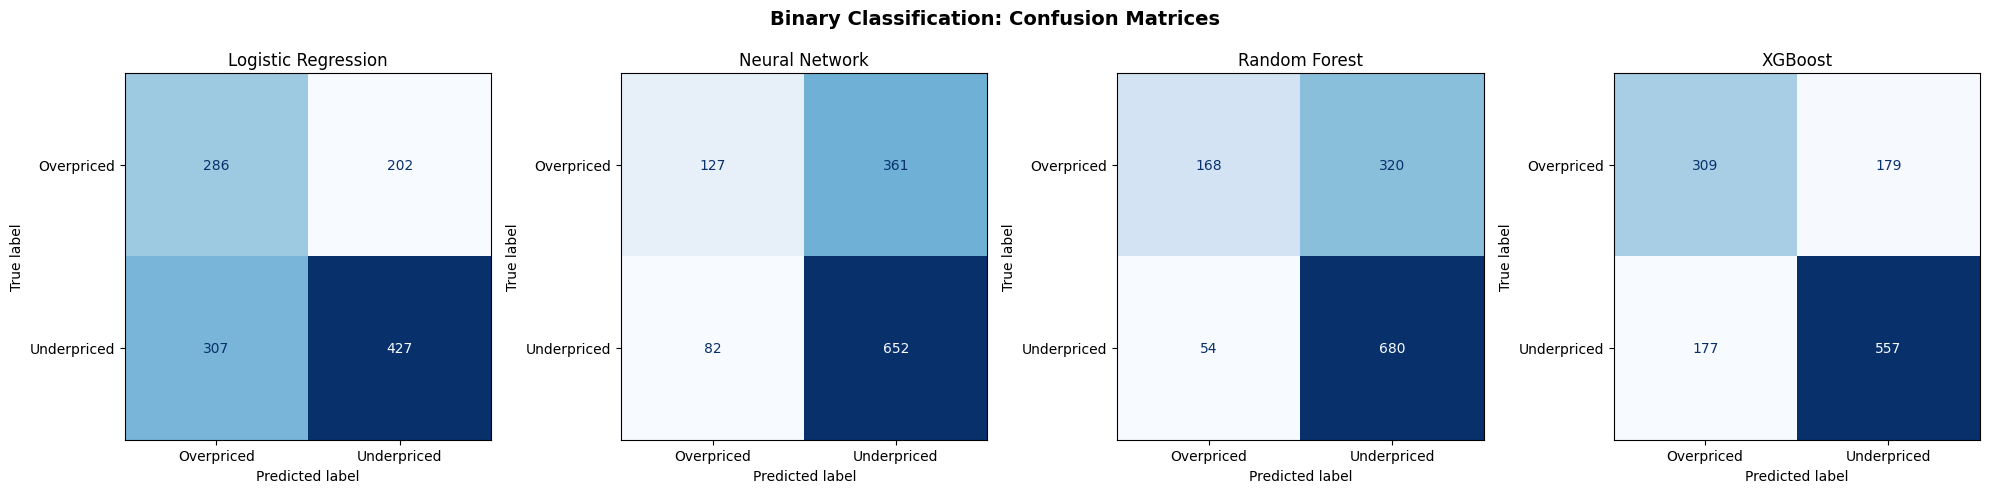

In [98]:
import torch
from sklearn.metrics import ConfusionMatrixDisplay
from src.pipeline import features, prepare_scaled, three_class
from src.models.logistic import LogisticRegression
from src.models.neural_network import NeuralNetwork
from src.models.random_forest import RandomForest
full = pd.read_csv("data/final/dataset_full.csv")
# Test Set and predictions for each model

X_train, X_test, y_train, y_test_binary = prepare_scaled(full,"underpriced",features)

#  loading Model predictions (Took too long to predict in notebok, so saved it)
lr_preds = np.load("src/models/saved_models/logistic/lr_binary_preds.npy")
nn_preds = np.load("src/models/saved_models/neural_network/nn_binary_preds.npy")
rf_preds = np.load("src/models/saved_models/random_forest/rf_binary_preds.npy")
xgb_preds = np.load("src/models/saved_models/xgBoost/xgb_binary_preds.npy")

fig, axes = plt.subplots(1,4, figsize=(20,5))
fig.suptitle("Binary Classification: Confusion Matrices", fontsize=14, fontweight="bold")

for ax, preds, name in zip(axes, [lr_preds, nn_preds, rf_preds, xgb_preds], ['Logistic Regression', 'Neural Network', 'Random Forest', 'XGBoost']):
    ConfusionMatrixDisplay.from_predictions(
        y_test_binary, preds,
        display_labels=['Overpriced', 'Underpriced'],
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

The confusion matrices reveal how each model handles the binary classification task and tell us more than accuracy alone. The most costly error appears in the top-right cell of each matrix, where the model predicts ***underpriced*** but the IPO is actually ***overpriced***. This is the worst mistake: an investor acting on that signal believes they are buying into an undervalued offering, but instead lose money on an overpriced one. A model that makes this error frequently is not just inaccurate, it is misleading. Among the four models, XGBoost is the most balanced and minimized that mistake most effectively. Neural Network and Random Forest, however, are heavily biased toward the majority class, leading them to overpredict "underpriced". These results are consistent with the weak F1 scores observed earlier. The confusion matrices support our claim that XGBoost is the preferred model and our case for it being used in the risk dataset.

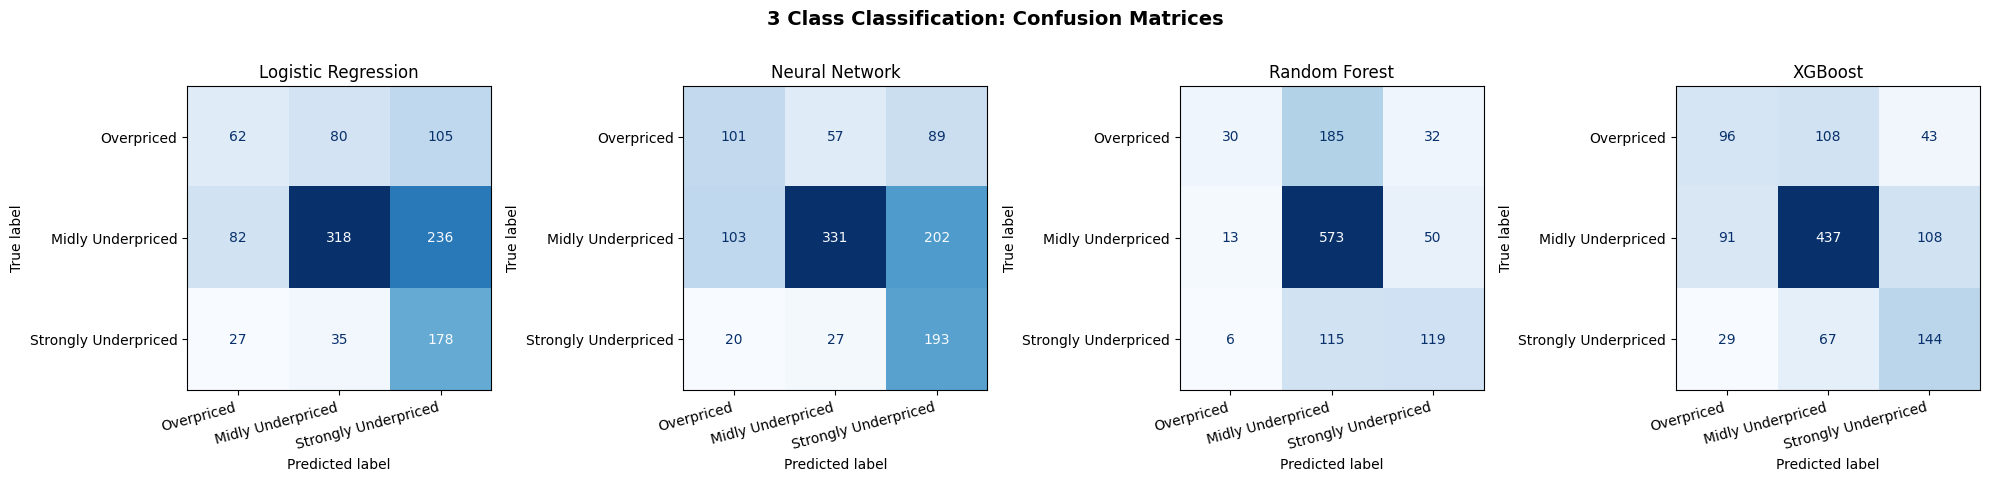

In [99]:
X_train, X_test, y_train, y_test_3class = prepare_scaled(three_class(full),"three_class",features)

lr_preds = np.load("src/models/saved_models/logistic/lr_3class_preds.npy")
nn_preds = np.load("src/models/saved_models/neural_network/nn_3class_preds.npy")
rf_preds = np.load("src/models/saved_models/random_forest/rf_3class_preds.npy")
xgb_preds = np.load("src/models/saved_models/xgBoost/xgb_3class_preds.npy")


fig, axes = plt.subplots(1,4, figsize=(20,5))
fig.suptitle("3 Class Classification: Confusion Matrices", fontsize=14, fontweight="bold")

for ax, preds, name in zip(axes, [lr_preds, nn_preds, rf_preds, xgb_preds], ['Logistic Regression', 'Neural Network', 'Random Forest', 'XGBoost']):
    ConfusionMatrixDisplay.from_predictions(
        y_test_3class, preds,
        display_labels=["Overpriced", "Midly Underpriced","Strongly Underpriced"],
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

The 3-class confusion matrices add nuance to our binary results by separating IPO underpricing into the two tiers mentioned in the Approach Section (Mildly and Strongly underpriced). The most costly error still remains the top cells where we predict mildly or strongly underpriced, and it is actually overpriced. The worst one being predicting strongly underpriced and getting a true label of overpriced. Across all four of our models, this mistake is not common, which is encouraging. The hardest challenge is distinguishing between a mildly and strongly underpriced IPO, shown by the middle right cells, especially in the Logistic Regression and Neural Network. Our Random Forest model collapses nearly everything in the mildly underpriced column, suggesting it is largely influenced by the majority class. XGBoost is again the most balanced, with the strongest diagonal and fewest catastrophic misclassifications. 
Overall, the 3-class task is meaningfully harder than the binary classification one, making our models less reliable. 

This shows us that for IPO underpricing binary classification of overpriced vs underpriced gives better and more consistent results


**Risk Dataset Results**

In this section, we look at our results for the risk dataset. As shown in the section above, XGBoost is our best model for binary and the one that is least impacted by class imbalance. As a result, we use XGBoost to assess whether risk score engineered from S-1 filings have an impact on predicting IPO underpricing vs a model without risk scores. 


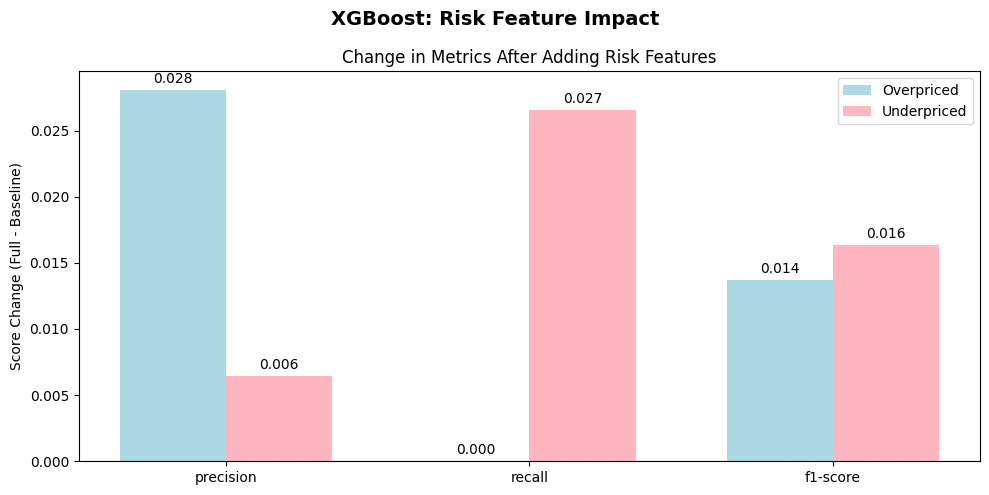

In [100]:
from src.pipeline import prepare_xgboost, features, risk_features
risk = pd.read_csv("data/final/dataset_with_risk.csv")
X_train, X_test_baseline, y_train, y_test_baseline = prepare_xgboost(risk, "underpriced", features)
X_train, X_test_full, y_train, y_test_full = prepare_xgboost(risk, "underpriced", risk_features)

with open("src/models/saved_models/xgBoost/xgb_baseline_risk.pkl", "rb") as f:
    xgb_baseline = pickle.load(f)
with open("src/models/saved_models/xgBoost/xgb_full_risk.pkl", "rb") as f:
    xgb_full = pickle.load(f)

preds_baseline = xgb_baseline.predict(X_test_baseline)
preds_full = xgb_full.predict(X_test_full)

report_baseline = classification_report(y_test_baseline, preds_baseline, target_names=["Overpriced", "Underpriced"], output_dict=True)
report_full = classification_report(y_test_full, preds_full, target_names=["Overpriced", "Underpriced"], output_dict=True)

classes=["Overpriced", "Underpriced"]
metrics= ["precision", "recall", "f1-score"]
x=np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("XGBoost: Risk Feature Impact", fontsize=14, fontweight="bold")
colors = ["lightblue", "lightpink"]
for i, cls in enumerate(classes):
    delta = [report_full[cls][m] -report_baseline[cls][m] for m in metrics]
    bars =ax.bar(x + i * width, delta, width, label=cls, color=colors[i])
    ax.bar_label(bars, fmt="%.3f", padding=3)

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score Change (Full - Baseline)")
ax.set_title("Change in Metrics After Adding Risk Features")
ax.legend()

plt.tight_layout()
plt.show()

Adding risk features produces small, consistent gains across all metrics with no single improvement exceeding 3 percentage points. While the direction is positive for precision, recall and f1 score, the changes are too marginal to be considered meaningful. This could be caused by the limited size of the dataset, restricting the model's ability to learn meaningful patterns from the additional features. A larger dataset with richer risk information could potentially lead to a larger difference. However, in our experiment, no meaningful difference is seen.

**Feature Importance**

This section examines which features most influence the XGBoost model's prediction, offering insight into the key drivers of IPO underpricing. We once again only use our XGBoost model because it was shown to be the best performing one.


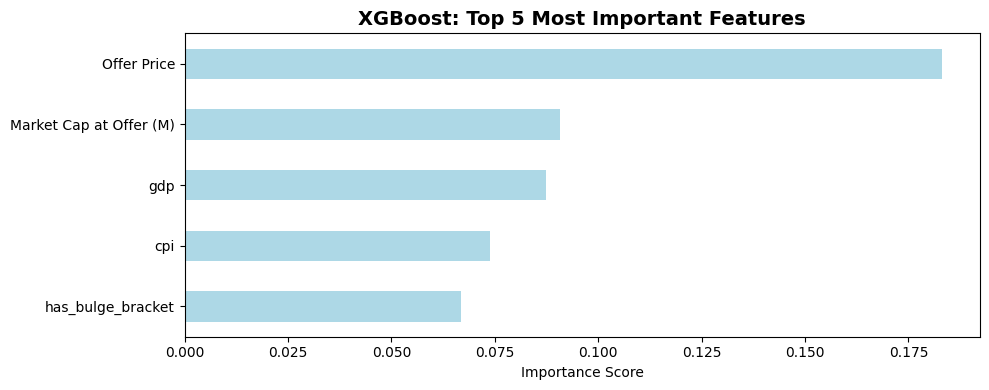

In [101]:
# Loading the model
with open("src/models/saved_models/xgBoost/xgb_binary_full.pkl", "rb") as f:
    xgb_binary = pickle.load(f)

importance = pd.Series(xgb_binary.feature_importances_, index=features).sort_values(ascending=False).head(5).sort_values(ascending=True)

fig,ax = plt.subplots(figsize=(10,4))
importance.plot(kind="barh", ax=ax, color="lightblue")
ax.set_title("XGBoost: Top 5 Most Important Features", fontsize=14, fontweight = "bold")
ax.set_xlabel("Importance Score")


plt.tight_layout()
plt.show()

The figure above shows the five most important features to predict IPO underpricing. The figure reveals that IPO underpricing is driven by a mix of deal-specific pricing, market size, and macroeconomic conditions. Offer Price dominates with an importance score of 0.18, nearly double the next feature, suggesting that the price at which an IPO is set relative to market expectations is the single strongest signal. Market Cap at Offer and GDP follow closely, both around 0.09, indicating that company size and the broader economic environment at the time of the offering are meaningful predictors. CPI comes in fourth, which reinforces that macroeconomic conditions, inflation, play a role in how IPOs do on the first day. Finally, whether the IPO was underwritten by a top-tier investment bank seems to have a strong effect. This is consistent with well-known financial relationship between underwriter prestige and IPO underpricing. Together, the features above showcase that pricing decisions and macro environment seem to matter more than firm-specific characteristics. 

### **Conclusion**
Our project demonstrated that machine learning models can be used to predict IPO underpricing with meaningful accuracy using financial and macroeconomic features. We successfully implemented four different models performing both binary and three-class classification across our full dataset, as well as the use of XGBoost on our risk dataset. Overall, we met our original goal of implementing and comparing the performance of multiple machine learning approaches for predicting IPO underpricing. 

Our findings are somewhat consistent with the existing literature on IPO prediction using machine learning, with ensemble-based methods such as XGBoost and Random Forest performing strongly. Our analysis of feature importance finds that macroeconomic conditions, pricing decisions, and underwriter prestige drive underpricing. While it is difficult to compare this with prior studies that use different data, features, and sample sizes, our results do confirm existing IPO underpricing theories around market timing and underwriter reputation. 

Given additional time, data, or computational resources, we would expand the size and feature diversity of our dataset, explore the use of more "established" variables as used by Colak et al. and more market sentiment variables. We would also further tune hyperparameters, compare our manual Random Forest to the superior `RandomForestClassifier` from the `sklearn` library, and evaluate model performance across different market conditions and time periods to improve predictive accuracy and generalizability.  

### **Group Contributions**
##### **Anna**
Throughout the project, I focused on the implementation of Logistic Regression and Random Forest. This primarily resulted in logistic.py, random_forest.py, train_logistic.py, train_randomForest.py and the accompanying notebooks that were used for initial model writing and training. I also set up an outline for the report and completed the Abstract, Introduction, Values, and Conclusion sections. 

##### **Will**

Throughout the project, I focused on the gathering/cleaning of the data, and implementation of the Neural Network and training XGBoost. This resulted in neural_network.py, train_NN.py, train_XGBoost.py, and the accompanying notebooks that were used for the initial model writing and training. I did the data gathering from the Bloomberg, wrote the data scripts found in scripts/data. For the report, I completed the Data, Our Approach, and Result sections. 

### **References**
[<sup id="fn1">[1]</sup>](#fn1-back)P. Sonsare, A. Pande, A. Kurve, S. Kumar, and C. Shanbhag, “A Comparative Analysis of Machine Learning Algorithms for Ipo Underperformance Prediction,” JOAASR, vol. 5, no. 6, pp. 1–12, Nov. 2023, doi: 10.46947/joaasr562023621.

[<sup id="fn2">[2]</sup>](#fn2-back)G. Colak, M. Fu, and I. Hasan, “Predicting IPO first-day returns: Evidence from machine learning analyses*,” Journal of Banking & Finance, vol. 178, p. 107500, Sep. 2025, doi: 10.1016/j.jbankfin.2025.107500.

[<sup id="fn3">[3]</sup>](#fn3-back)B. Zhao and H. Long, “Machine Learning in Initial Public Offering Underpricing: Managerial Implications for China,” PJMS, vol. 32, no. 2, pp. 253–265, Dec. 2025, doi: 10.17512/pjms.2025.32.2.16.